# PCHN63112 Workshop: Clustered Longitudinal Data Example
In this example,we will examine building a mixed-effects model for longitudinal data that are also clustered. This will demonstrate how the multilevel framework extends beyond two levels, as well as how this can be integrated into a mixed-effects model. This is also a larger example, especially when interactions are considered. This will lead to a more complex expression for the model, but one which is a simple generalisation of other examples we have seen. Of particular importance is that this example shows a model where *all* the variables are continuous. This will be an important bridge before seeing examples that are a *mixture* of categorical and continuous.

## Loading Packages
We will start by loading all the packages that we need at the beginning. This will tidy-up the output, allow any messages or warnings to not clutter up the rest of the output and not bury any packages within the main body of the analysis. We also use `source()` on the file `plot-lme.R`. This needs to be in the current working directory and will bring the custom function `plot.lme()` into scope.

In [1]:
library('lattice')   # plotting functions
library('Matrix')    # covariance extraction and visualisation
library('nlme')      # mixed-effects modelling
library('car')       # Asymptotic ANOVA tests
library('effects')   # Effects plots from the model
source('plot-lme.R') # custom plot.lme() function for making assumptions plots

Loading required package: carData
Use the command
    lattice::trellis.par.set(effectsTheme())
  to customize lattice options for effects plots.
See ?effectsTheme for details.


## The Dental Veneer Data
The data we will use concern measurements of Gingival Crevicular Fluid (GRF) taken adjacent to newly placed dental veneers. In this study, researchers were interested in subsequent gum health after ceramic veneers were fitted to different teeth in a selection of patients. These veneers are designed to hide discolouration and are attached by first removing some tooth surface and then using a special adhesive to secure the veneer in place. Of particular interest was whether any difference in contour between the original tooth and the veneer was associated with increased levels of GRF over time. The researchers took measurements of GRF at the time when the veneers were fitted (the baseline GRF) as well as measurements 3 months and 6 months post-treatment.

The data can be downloaded from [here](https://websites.umich.edu/~bwest/chapter7.html). Once downloaded to the current working directory, the code below will read the data into `R` and then print values for all the teeth from the first two patients. 

In [2]:
veneer <- read.table('veneer.dat', header=TRUE)
veneer[1:24,]

   patient tooth age base_gcf       cda time gcf
1        1     6  46       17  4.666667    3  11
2        1     6  46       17  4.666667    6  68
3        1     7  46       22  4.666667    3  13
4        1     7  46       22  4.666667    6  47
5        1     8  46       18  5.000000    3  14
6        1     8  46       18  5.000000    6  58
7        1     9  46       12  3.333333    3  10
8        1     9  46       12  3.333333    6  57
9        1    10  46       10  8.666667    3  14
10       1    10  46       10  8.666667    6  44
11       1    11  46       17  5.666667    3  11
12       1    11  46       17  5.666667    6  53
13       3     6  32        3  7.666667    3  28
14       3     6  32        3  7.666667    6  23
15       3     7  32        4 11.000000    3  17
16       3     7  32        4 11.000000    6  15
17       3     8  32        3 10.666670    3  19
18       3     8  32        3 10.666670    6  32
19       3     9  32       10 10.000000    3  34
20       3     9  32

There are a few variables here, so we split them into those that relate to each *patient* as a whole, each *tooth* as a whole and each *time point*.

- Patient
    - `patient`: the unique identifier of each *patient*
    - `age`: the patient's age
- Tooth
    - `tooth`: the unique identifier of each *tooth*
    - `base_gcf`: the baseline measure of GCF for that tooth
    - `cda`: the *curvature difference* between the original tooth and the veneer
- Time
    - `time`: the time in months after fitting the veneer
    - `gcf`: **the measurement of Gingival Crevicular Fluid (GCF) at that time point**

Some of these variables are indices to keep things organised and to allow us to define different levels of the data (e.g. `patient` and `tooth`). The outcome variable is `gcf`, highlighted in **bold**, indicative of the amount of Gingival Crevicular Fluid (GCF) measured adjacent to a given tooth at a particular time point. Of primary interest is the relationship with CDA and how it interacts with the amount of GCF over time. Also of interest is assessing how the amount of baseline GCF interacts with time. For instance, patients with greater GCF at baseline may show a different change over time compared to those with less GCF at baseline. Finally, the patients age should also be considered, as older adults can exhibit higher levels of GCF than younger adults.

As these data are already long-formatted, we just need to convert the relevant variables to factors.

In [3]:
veneer$patient <- as.factor(veneer$patient)
veneer$tooth   <- as.factor(veneer$tooth)

We can now briefly summarise all the variables. At this stage, we would usually produce some plots and do further data checking and wrangling, but we will leave this step to one side to keep the example shorter.

In [4]:
summary(veneer)

    patient   tooth        age           base_gcf          cda        
 1      :12   6 :16   Min.   :21.00   Min.   : 3.00   Min.   :-3.000  
 3      :12   7 :20   1st Qu.:29.00   1st Qu.:10.00   1st Qu.: 3.417  
 4      :12   8 :20   Median :46.00   Median :15.00   Median : 5.000  
 6      :12   9 :18   Mean   :39.87   Mean   :17.38   Mean   : 5.182  
 7      :12   10:22   3rd Qu.:50.75   3rd Qu.:25.00   3rd Qu.: 7.250  
 8      :12   11:14   Max.   :62.00   Max.   :42.00   Max.   :11.000  
 (Other):38                                                           
      time          gcf       
 Min.   :3.0   Min.   : 3.00  
 1st Qu.:3.0   1st Qu.:10.00  
 Median :4.5   Median :17.50  
 Mean   :4.5   Mean   :23.59  
 3rd Qu.:6.0   3rd Qu.:32.00  
 Max.   :6.0   Max.   :87.00  
                              

Of note is that there are unbalanced representations of each level of `tooth`, given that not every patient had veneers fit to the same teeth.

### Model Notation
As these data are all *continuous* variables, a more general regression framework will be needed when writing this model. In what follows, we will use $\beta$-coefficients for continuous variables (e.g. $\beta_{1} \times \text{CDA}_{i}$ rather than $\beta_{1}x_{i1}$). This should hopefully make it clearer which variable each term relates to when writing the model down.

## Data Structure
Although we already know what structure these data have, we will run through the logic for completeness.

Firstly, we need to determine our *unit of analysis*. In this example, our model is trying to explain change in GCF measured adjacent to *teeth*. The entities that our model is describing are the *teeth* themselves, not the patients who contain the teeth. From the perspective of a psychologist, this can sound off. However, remember that dentists care about *teeth*, not necessarily the person that the teeth belong to.

Secondly, we determine what each *row* of the long-formatted data represents in relation to the units of analysis. Examining the first few rows

In [5]:
head(veneer)

  patient tooth age base_gcf      cda time gcf
1       1     6  46       17 4.666667    3  11
2       1     6  46       17 4.666667    6  68
3       1     7  46       22 4.666667    3  13
4       1     7  46       22 4.666667    6  47
5       1     8  46       18 5.000000    3  14
6       1     8  46       18 5.000000    6  58

we can see that each row corresponds to a single unit (*tooth*) measured *twice*. So these are either *repeated measurements* or *longitudinal* data. The difference lies in whether there is an explicit measurement of time here. As we can see, the different repeats are indexed by the values of `time`. Importantly, these values have an *order* that must be maintained and the temporal gap between successive values is important. The time scale is also meaningful, as it is measured in *months*. As such, this is *longitudinal* data.

Finally, we need to determine whether there are any *clustering* variables that represent a higher-order dependency structure in these data. As we can see from printing the data earlier, the only categorical measurement that is constant across different sets of teeth is `patient`. This is entirely indicative of a shared context or environment that binds different teeth together. All the teeth from the same individual are very likely to be correlated to some degree. The `patient` is something that each tooth is *IN* rather than something each tooth *HAS*. Indeed, this is one of the clearest real-world examples of clustering as it is very obvious how teeth from the same person share an environment that may impact all of them in a similar way. As such, `patient` is a clustering variable, making these data *clustered longitudinal*. Based on this, we can construct the following table of the *levels* of these data, using the guidance in the lesson

| **Data Type**    | **Clustered Longitudinal** | 
|------------------|----------------------------|
| **Dataset**      | `veneer`                   |
| **Level 1**      | Time                       |
| **Level 2**      | *Tooth*                    |
| **Level 3**      | Patient                    |

We can get an initial sense of the structure of these data by plotting the different levels in the following way.

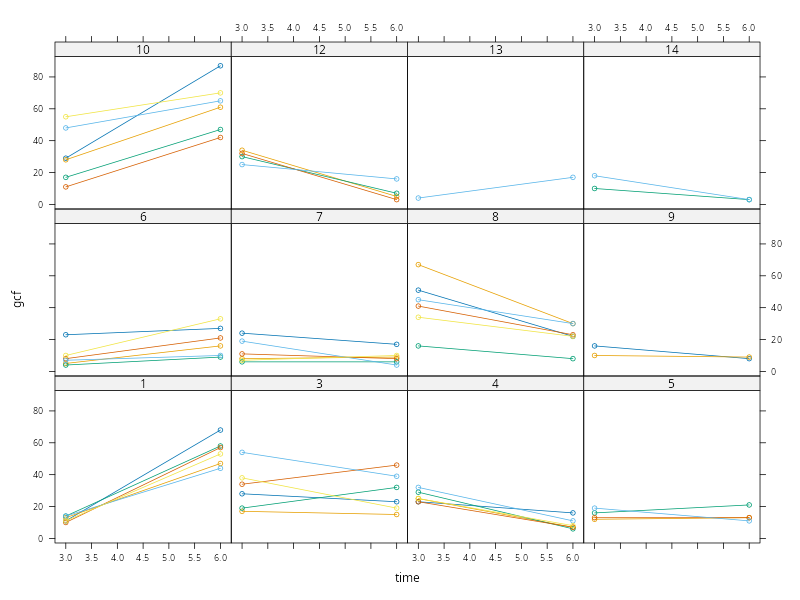

In [6]:
xyplot(
  gcf ~ time|patient, # x-axis=time, panel=patient
  groups = tooth,     # separate lines per-tooth
  data   = veneer,    # data
  type   = "b"        # lines with points
)

Of note is that the trajectory of GCF tends to be similar across all teeth from the same patient, but can differ a lot from patient-to-patient. We can also see the different numbers of trajectories per-patient, given that only some teeth were fitted with veneers for each person. This drives home the idea that the teeth are a random sample within each patient, and each patient is a random sample from a wider population. This conceptualisation will help in terms of the model building.

## Model Building
To build a model of this dataset, we use the 3-step procedure outlined in the lesson. We assume at this point that the data has been investigated, wrangled, cleaned and ready for modelling.

### Step I: A Single Dependency Structure
We start by isolating a single dependency structure. This needs to be at the *lowest* level, with no further dependency structures within. In this example, this is a single *tooth* from a single *patient*. We choose `tooth == '6'` within `patient == '1'` as the example, subsetting the data below

In [7]:
patient.1 <- subset(veneer,    patient == '1')
tooth.6   <- subset(patient.1, tooth   == '6')

print(tooth.6)

  patient tooth age base_gcf      cda time gcf
1       1     6  46       17 4.666667    3  11
2       1     6  46       17 4.666667    6  68


In terms of variables suitable for modelling the effect of *time* for a single tooth, we note that `age`, `cda` and `base_gcf` are *constant*, given that they are defined at the level of each *tooth* or *patient* as a whole. As such, we remove them from the dataset

In [8]:
tooth.6 <- subset(patient.1, tooth == '6', select=c(-age,-base_gcf,-cda))
print(tooth.6)

  patient tooth time gcf
1       1     6    3  11
2       1     6    6  68


Now we can see that the only variables left are the outcome variable `gcf` and the continuous predictor of `time`. As such, our basic model for a single tooth is

$$
\text{GCF}_{i} = \beta_{0} + (\beta_{1} \times \text{time}_{i}) + \eta_{i}
$$

where $i$ indexes *time*. Already a problem should be visible, as we only have two measurements per-tooth. As such, the model fit will be *perfect* and there will be no residual variance left. We can see this below

In [9]:
tooth.6.lm <- lm(gcf ~ 1 + time, data=tooth.6)
summary(tooth.6.lm)


Call:
lm(formula = gcf ~ 1 + time, data = tooth.6)

Residuals:
ALL 2 residuals are 0: no residual degrees of freedom!

Coefficients:
            Estimate Std. Error t value Pr(>|t|)
(Intercept)      -46        NaN     NaN      NaN
time              19        NaN     NaN      NaN

Residual standard error: NaN on 0 degrees of freedom
Multiple R-squared:      1,	Adjusted R-squared:    NaN 
F-statistic:   NaN on 1 and 0 DF,  p-value: NA


This means that we will not be able to estimate a unique effect of `time` for each tooth from each `patient`. Thinking slightly ahead, this means that we can only fit a *random intercept* per-tooth, rather than a random intercept + slope with `time`. This is not necessarily an issue. Looking back at the profiles plot above, teeth within each patient tend to show a similar effect of `time`, so there is no obvious need to allow the *slope* of each tooth to differ randomly within each patient. The teeth themselves do appear to differ randomly in terms of their absolute amount of GCF, justifying a random intercept per-tooth. However, differences in the effect of `time` appear to exist at the level of a *patient* as a whole. As such, integration of a random intercept + slope model at the level of *patient* would be more in-keeping with the patterns in the data, rather than a random intercept + slope model at the level of each *tooth*.

### Step II: Expand to Multiple Structures
In our second step, we expand the model above to *multiple* teeth from the same patient. We index these using the notation of $(t)$, to indicate which terms *belong* to a particular *tooth*. We start with the most general case of allowing every term to vary by-tooth, giving us

$$
\text{GCF}^{(t)}_{i} = \beta_{0}^{(t)} + \left(\beta^{(t)}_{1} \times \text{time}_{i}\right) + \eta^{(t)}_{i}.
$$

We can now reason more carefully about each of these.

In terms of the intercept, if we wish to use a mixed-effects model then the bear minimum is a *random intercept*. This alone could be enough to decide on this term, but it is worth considering the *meaning* of doing this as well, especially as we could still include a random intercept at the level of each *patient*, even if we did not at the level of each *tooth*. In the current model, the intercept represents the average amount of GCF for tooth $t$. If we choose to *fix* this value, we are saying that *all* teeth start with the same amount of GCF and any variability is simply sampling error. In other words, *different teeth do not matter*. By allowing this term to vary randomly, we are saying that the amount of GCF differs depending upon the specific tooth, encoding the idea that each tooth is a random sample from a population of teeth. Given the discussion above, it makes most sense to treat teeth in this way and thus we choose to allow the intercept to vary randomly.

In terms of the `time` slope, we have two different considerations here. Firstly, we know from above that the data do not support a random slope of `time` per-tooth. As such, this is not *practically* possible. However, we also need to think about whether *conceptually* this is something that we would desire and whether being forced to fix this value is a fundamental limitation of these data. If we were to allow the slope per-tooth to vary, this would suggest that each tooth has its own unique trajectory across time. In other words, the specific tooth *does matter* in terms of the time-effect. For this particular example, there are two reasons to think this may not be necessary. Firstly, from a purely theoretical perspective, all teeth within a single patient are likely to change in a similar way across time. A person's mouth is not partitioned in such a way that some teeth may be able to change in a fashion that is completely different from other teeth. Any changes that affect GCF for one tooth are likely to apply to all other teeth from the same mouth. Secondly, we can see from plotting the data that trajectories of teeth from the same person look very similar to each other. In fact, the main difference is the *height* of the slopes, which is already covered by the random intercept. If we remove these height differences, the slopes would be so similar that any differences between teeth from the same patient can most likely be considered sampling error. As such, there seems little *theoretical* or *data-driven* reason to allow the effect of time to differ on a per-tooth basis. For all these reasons, we shall *fix* the effect of time across teeth.

### Step III: Write the Higher-level Models
Now that we have made a decision about all the Level 1 terms, we can write the Level 2 models for each term. Given that only the intercept is random per-tooth, this is the only Level 2 model that gets an error term $\left(\xi_{0}^{(t)}\right)$, leading to

$$
\begin{alignat*}{1}
\text{Level 1 (Time)} \\
    \text{GCF}^{(t)}_{i} &= \beta_{0}^{(t)} + \left(\beta^{(t)}_{1} \times \text{time}_{i}\right) + \eta^{(t)}_{i} \\ \quad \\
\text{Level 2 (Tooth)} \\
    \beta_{0}^{(t)} &= \beta_{0} + \xi_{0}^{(t)} \\
    \beta^{(t)}_{1} &= \beta_{1}. \\
\end{alignat*}
$$

We can now consider adding further predictor variables to the Level 2 models of teeth as a whole. Looking back at the table from earlier, both `base_GCF` and `cda` are defined at the level of individual teeth. We can add both of these terms to the model of the intercept like so

$$
\begin{alignat*}{1}
\text{Level 1 (Time)} \\
    \text{GCF}^{(t)}_{i} &= \beta_{0}^{(t)} + \left(\beta^{(t)}_{1} \times \text{time}_{i}\right) + \eta^{(t)}_{i}. \\ \quad \\
\text{Level 2 (Tooth)} \\
    \beta_{0}^{(t)} &= \beta_{0} + \left(\beta_{2} \times \text{GCFb}^{(t)}\right) + \left(\beta_{3} \times \text{CDA}^{(t)}\right) + \xi_{0}^{(t)} \\
    \beta^{(t)}_{1} &= \beta_{1}. \\
\end{alignat*}
$$

So, now we have a model where the intercept for a given tooth depends upon the amount of GCF at time 0 across all teeth $\left(\beta_{0}\right)$, plus a shift depending upon the actual amount of GCF recorded for that tooth at baseline $\left(\beta_{2}\right)$ plus the effect of the curvature discrepancy for that specific tooth $\left(\beta_{3}\right)$.

We can also add these terms to the model for the *slope* as well. Importantly, these terms will shift the slope depending on these other predictor variables. As such, these represent *interactions* with `time`. This will become more apparent when we collapse the levels together because each of these terms will then be *multiplied* by $\text{time}_{i}$. Not every model will justifiably include interactions of this form. However, we are specifically interested in the effects of `time` on `gcf` and have reason to think that baseline levels of GCF and CDA could change how time affects each tooth. So, for us, the model form is as follows

$$
\begin{alignat*}{1}
\text{Level 1 (Time)} \\
    \text{GCF}^{(t)}_{i} &= \beta_{0}^{(t)} + \left(\beta^{(t)}_{1} \times \text{time}_{i}\right) + \eta^{(t)}_{i}. \\ \quad \\
\text{Level 2 (Tooth)} \\
    \beta_{0}^{(t)} &= \beta_{0} + \left(\beta_{2} \times \text{GCFb}^{(t)}\right) + \left(\beta_{3} \times \text{CDA}^{(t)}\right) + \xi_{0}^{(t)} \\
    \beta^{(t)}_{1} &= \beta_{1} + \left(\beta_{4} \times \text{GCFb}^{(t)}\right) + \left(\beta_{5} \times \text{CDA}^{(t)}\right)  \\
\end{alignat*}
$$

So, now we have a model where, in addition to the intercept for a given tooth, the effect of time on that tooth depends upon the effect of time across all teeth $\left(\beta_{1}\right)$, plus a shift in the slope that depends upon the actual amount of GCF recorded for that tooth at baseline $\left(\beta_{4}\right)$ plus a shift in the slope that depends upon the the curvature discrepancy for that specific tooth $\left(\beta_{5}\right)$.

#### Expand to Multiple Patients
... Once we expand to multiple patients, we also need to recognise that each tooth is not some free-floating unit as it *has* to be within a given patient. As such, we need to change our notation a little to $(t|p)$, which we can read as *tooth $t$ within patient $p$*.


$$
\begin{alignat*}{1}
\text{Level 2 (Tooth)} \\
    \beta_{0}^{(t|p)} &= \beta^{(p)}_{0} + \left(\beta^{(p)}_{2} \times \text{GCFb}^{(t|p)}\right) + \left(\beta^{(p)}_{3} \times \text{CDA}^{(t|p)}\right) + \xi_{0}^{(t|p)} \\
    \beta^{(t|p)}_{1} &= \beta^{(p)}_{1} + \left(\beta^{(p)}_{4} \times \text{GCFb}^{(t|p)}\right) + \left(\beta^{(p)}_{5} \times \text{CDA}^{(t|p)}\right) \\ \quad \\
\text{Level 3 (Patient)} \\
    \beta^{(p)}_{0} &= \beta_{0} + \left(\beta_{6} \times \text{age}^{(p)}\right) + \phi_{0}^{(p)} \\
    \beta^{(p)}_{1} &= \beta_{1} + \left(\beta_{7} \times \text{age}^{(p)}\right) + \phi_{1}^{(p)} \\
    \beta^{(p)}_{2} &= \beta_{2}  \\
    \beta^{(p)}_{3} &= \beta_{3} \\
    \beta^{(p)}_{4} &= \beta_{4} \\
    \beta^{(p)}_{5} &= \beta_{5} 
\end{alignat*}
$$

... The full model is

$$
\begin{alignat*}{1}
\text{Level 1 (Time)} \\
    \text{GCF}^{(t)}_{i} &= \beta_{0}^{(t)} + \left(\beta^{(t)}_{1} \times \text{time}_{i}\right) + \eta^{(t)}_{i}. \\ \quad \\
\text{Level 2 (Tooth)} \\
    \beta_{0}^{(t)} &= \beta^{(p)}_{0} + \left(\beta^{(p)}_{2} \times \text{GCFb}^{(t)}\right) + \left(\beta^{(p)}_{3} \times \text{CDA}^{(t)}\right) + \xi_{0}^{(t)} \\
    \beta^{(t)}_{1} &= \beta^{(p)}_{1} + \left(\beta^{(p)}_{4} \times \text{GCFb}^{(t)}\right) + \left(\beta^{(p)}_{5} \times \text{CDA}^{(t)}\right) \\ \quad \\
\text{Level 3 (Patient)} \\
    \beta^{(p)}_{0} &= \beta_{0} + \left(\beta_{6} \times \text{age}^{(p)}\right) + \phi_{0}^{(p)} \\
    \beta^{(p)}_{1} &= \beta_{1} + \left(\beta_{7} \times \text{age}^{(p)}\right) + \phi_{1}^{(p)} \\
    \beta^{(p)}_{2} &= \beta_{2}  \\
    \beta^{(p)}_{3} &= \beta_{3} \\
    \beta^{(p)}_{4} &= \beta_{4} \\
    \beta^{(p)}_{5} &= \beta_{5} 
\end{alignat*}
$$

which we can simplify by collapsing the fixed-effects back into the different levels to give

$$
\begin{alignat*}{1}
\text{Level 1 (Time)} \\
    \text{GCF}^{(t)}_{i} &= \beta_{0}^{(t)} + \left(\beta^{(p)}_{1} \times \text{time}_{i}\right) + \left(\beta_{4} \times \text{GCFb}^{(t)} \times \text{time}_{i}\right) + \left(\beta_{5} \times \text{CDA}^{(t)} \times \text{time}_{i}\right) + \eta^{(t)}_{i}. \\ \quad \\
\text{Level 2 (Tooth)} \\
    \beta_{0}^{(t)} &= \beta^{(p)}_{0} + \left(\beta_{2} \times \text{GCFb}^{(t)}\right) + \left(\beta_{3} \times \text{CDA}^{(t)}\right) + \xi_{0}^{(t)} \\ \quad \\
\text{Level 3 (Patient)} \\
    \beta^{(p)}_{0} &= \beta_{0} + \left(\beta_{6} \times \text{age}^{(p)}\right) + \phi_{0}^{(p)} \\
    \beta^{(p)}_{1} &= \beta_{1} + \left(\beta_{7} \times \text{age}^{(p)}\right) + \phi_{1}^{(p)} \\
\end{alignat*}
$$

## Fitting the Model in `R`

$$
\begin{alignat*}{1}
    \text{GCF}^{(t)}_{i} = &\: \beta_{0} + \left(\beta_{1} \times \text{time}_{i}\right) + \left(\beta_{2} \times \text{GCFb}^{(t)}\right) + \left(\beta_{3} \times \text{CDA}^{(t)}\right) + \left(\beta_{6} \times \text{age}^{(p)}\right) + \\ 
    &\left(\beta_{4} \times \text{GCFb}^{(t)} \times \text{time}_{i}\right) + \left(\beta_{5} \times \text{CDA}^{(t)} \times \text{time}_{i}\right) + \left(\beta_{7} \times \text{age}^{(p)} \times \text{time}_{i}\right) + \\
    &\xi_{0}^{(t)} + \phi_{0}^{(p)} + \left(\phi_{1}^{(p)} \times \text{time}_{i}\right) + \eta^{(t)}_{i} 
\end{alignat*}
$$

which does look quite complicated, but consists of an intercept $(\beta_{0})$; slopes with `time` $(\beta_{1})$, `baseline_GCF` $(\beta_{2})$, `CDA` $(\beta_{3})$ and `age` $(\beta_{6})$; interactions `baseline_GCF:time` $(\beta_{4})$, `CDA:time` $(\beta_{5})$ and `age:time` $(\beta_{7})$; a random intercept per-tooth $\left(\xi_{0}^{(t)}\right)$, a random intercept and `time` slope per-patient $\left(\phi_{0}^{(p)}, \phi_{1}^{(p)}\right)$ and a final error term $\left(\eta^{(t)}_{i}\right)$.

In terms of specifying this in `R`, the fixed-effects are straightforward as the description above leads to `fixed = gcf ~ 1 + base_gcf + cda + time + age + time:base_gcf + time:cda + time:age`. For the random effects, we start with the error terms

$$
\xi_{0}^{(t)} + \phi_{0}^{(p)} + \left(\phi_{1}^{(p)} \times \text{time}_{i}\right) + \eta^{(t)}_{i}
$$

and then remove the final errors, as they do not need to be explicitly specified.

$$
\xi_{0}^{(t)} + \phi_{0}^{(p)} + \left(\phi_{1}^{(p)} \times \text{time}_{i}\right).
$$

We then change the conditional notation to give

$$
\begin{alignat*}{1}
    \xi_{0} &\:|\: t \\
    \phi_{0} + \left(\phi_{1} \times \text{time}_{i}\right) &\:|\: p \\
\end{alignat*}
$$

implying that we need both `1|tooth` and `1 + time|patient` in the model. 

How do we do this? The way `lme()` handles this situation is by passing a `list` to the `random=` option. Within this list, we label each field using the relevant factor variable and then give the model formula. Due to the labelling, the conditional syntax is implied and does not need to be given explicitly. So, for both `1|tooth` and `1 + time|patient` we can use `list(tooth = ~ 1, patient = ~ 1 + age)`. This gives us full control of the random-effects specification at each level. Our model can therefore be expressed to `lme()` using the following syntax

In [10]:
veneer.lme <- lme(fixed   = gcf ~ 1 + base_gcf + cda + time + age + time:base_gcf + time:cda + time:age,
                  random  = list(tooth   = ~ 1,
                                 patient = ~ 1 + time),
                  data    = veneer, 
                  control = lmeControl(opt='optim') 
) 

which we can print to check

In [11]:
print(veneer.lme)

Linear mixed-effects model fit by REML
  Data: veneer 
  Log-restricted-likelihood: -459.1694
  Fixed: gcf ~ 1 + base_gcf + cda + time + age + time:base_gcf + time:cda +      time:age 
  (Intercept)      base_gcf           cda          time           age 
  88.89247933   -0.26927505   -2.30330590  -11.18323137   -1.30710933 
base_gcf:time      cda:time      time:age 
   0.05086456    0.62792054    0.19630363 

Random effects:
 Formula: ~1 | tooth
        (Intercept)
StdDev:    2.480235

 Formula: ~1 + time | patient %in% tooth
 Structure: General positive-definite, Log-Cholesky parametrization
            StdDev    Corr  
(Intercept) 18.708417 (Intr)
time         5.659124 -0.922
Residual     9.960779       

Number of Observations: 110
Number of Groups: 
             tooth patient %in% tooth 
                 6                 55 


In [12]:
Sigma.1 <- try(getVarCov(veneer.lme))

Error in getVarCov.lme(veneer.lme) : 
  not implemented for multiple levels of nesting


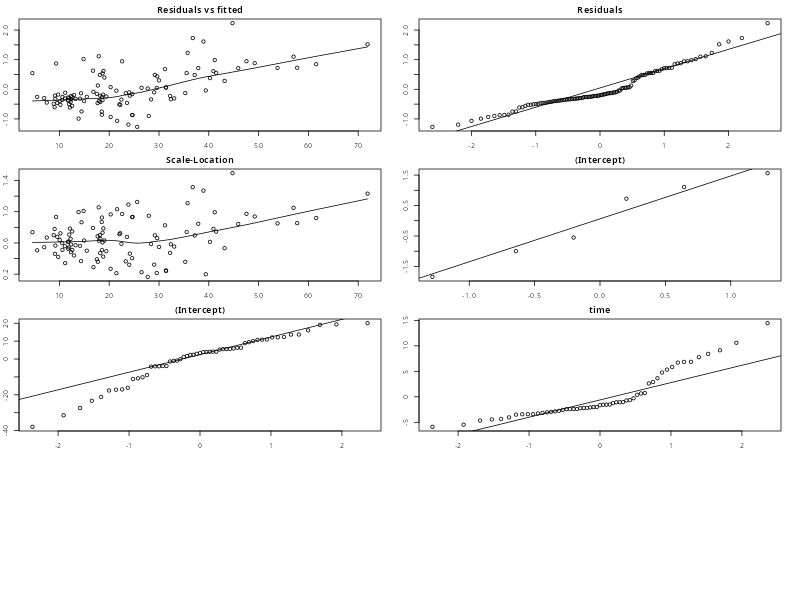

Warning message:
In plot.lme(veneer.lme) :
  Marginal covariance structure not available for more than 2 levels


In [13]:
plot.lme(veneer.lme)

In [14]:
vif(veneer.lme)

     base_gcf           cda          time           age base_gcf:time 
     8.321834      8.480576     37.151996      7.962650     12.208380 
     cda:time      time:age 
    12.435790     22.079264 

So, this looks like we have a *very* big problem with multicolinearity. Notice that the biggest culprit is between `time` and its interactions. Often, this can be down to using *un-centered* continuous variables. Centering (the act of removing the mean from each variable) helps separate-out the main effect from the interaction when using continuous variables. In doing so, we can dramatically reduce the overlap in the model terms. When working with models like this that contain continuous interactions, it is often a good idea to start by centering all the variables and see if this resolves the problem. In `R`, this can be done using   

In [15]:
veneer$base_gcf.c <- veneer$base_gcf - mean(veneer$base_gcf)
veneer$cda.c      <- veneer$cda      - mean(veneer$cda) 
veneer$time.c     <- veneer$time     - mean(veneer$time)
veneer$age.c      <- veneer$age      - mean(veneer$age)

veneer.lme <- lme(fixed   = gcf ~ 1 + base_gcf.c + cda.c + time.c + age.c + time.c:base_gcf.c + time.c:cda.c + time.c:age.c,
                  random  = list(tooth   = ~ 1,
                                 patient = ~ 1 + time.c),
                  data    = veneer, 
                  control = lmeControl(opt='optim') 
) 

vif(veneer.lme)

       base_gcf.c             cda.c            time.c             age.c 
         1.701232          1.754961          1.000000          1.604670 
base_gcf.c:time.c      cda.c:time.c      time.c:age.c 
         1.679292          1.732705          1.590532 

As we can see, the problem has now disappeared. Note, if there is still high VIF even *after* centering, then there is a more fundamental issue with the variables in question. Luckily, we do not have this here and so can continue without any other intervention.

## Inference

In [16]:
Anova(veneer.lme)

Analysis of Deviance Table (Type II tests)

Response: gcf
                    Chisq Df Pr(>Chisq)    
base_gcf.c         0.2222  1    0.63737    
cda.c              0.0006  1    0.97979    
time.c             0.6228  1    0.43000    
age.c             16.4971  1  4.872e-05 ***
base_gcf.c:time.c  0.2038  1    0.65168    
cda.c:time.c       2.7124  1    0.09957 .  
time.c:age.c       4.4178  1    0.03557 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Note that because these are all single degree-of-freedom tests, there is no need for any follow-up tests. These are not omnibus tests. Instead, these can be taken as asymptotic equivalents to the coefficients tests in the regression table. 

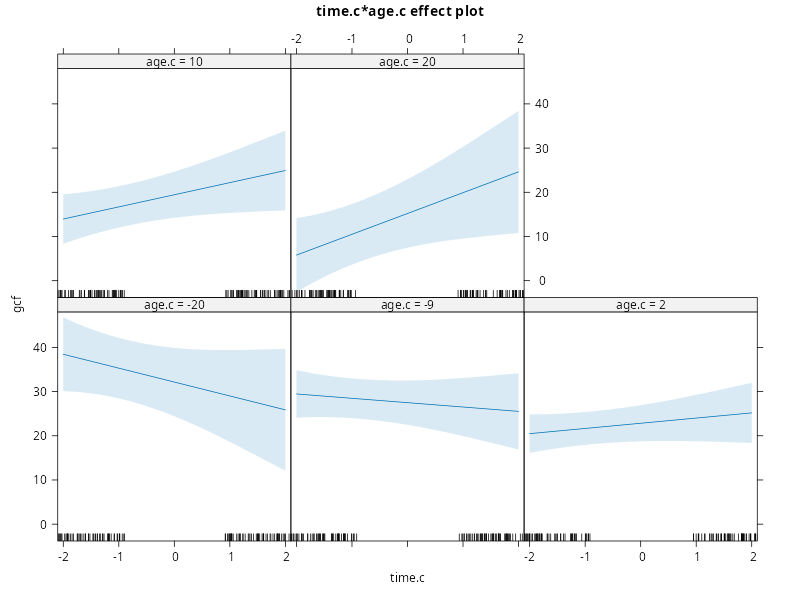

In [17]:
plot(effect('time.c:age.c', veneer.lme))

By default, when plotting a continuous x continuous interaction, the `effect()` function will choose 5 values of one predictor over which to display the slope of the other predictor. So, in this example, 5 values of `age` have been chosen to illustrate how the slope with `time` changes. This can be controlled using the `xlevels` argument, which we can set to a single value to control the number of equally-spaced values chosen. For instance, if we used `xlevels=20`, we would get

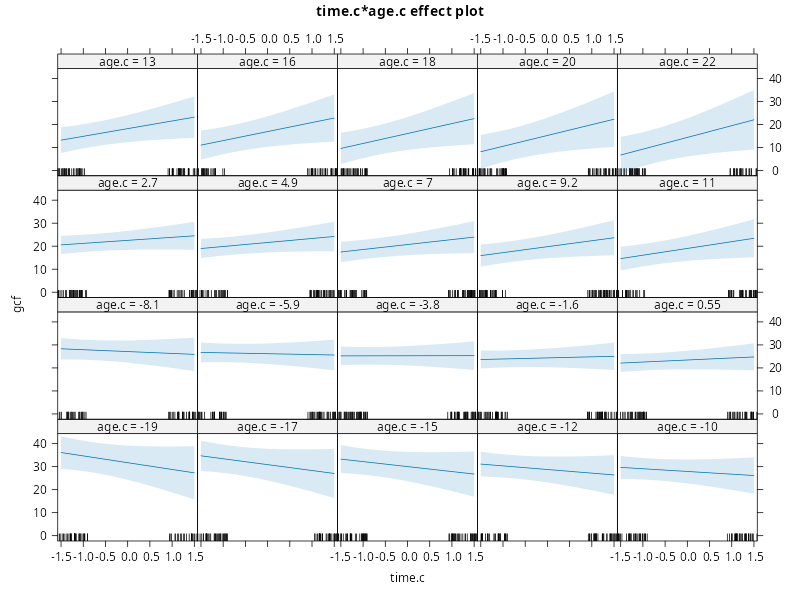

In [18]:
plot(effect('time.c:age.c', veneer.lme, xlevels=20))

The only problem we have here is that the plots are constructed on the *centered* scale, which is difficult to interpret in terms of the original scale of each variable. To accommodate this, we can calculate the effects first and then rescale them before plotting.

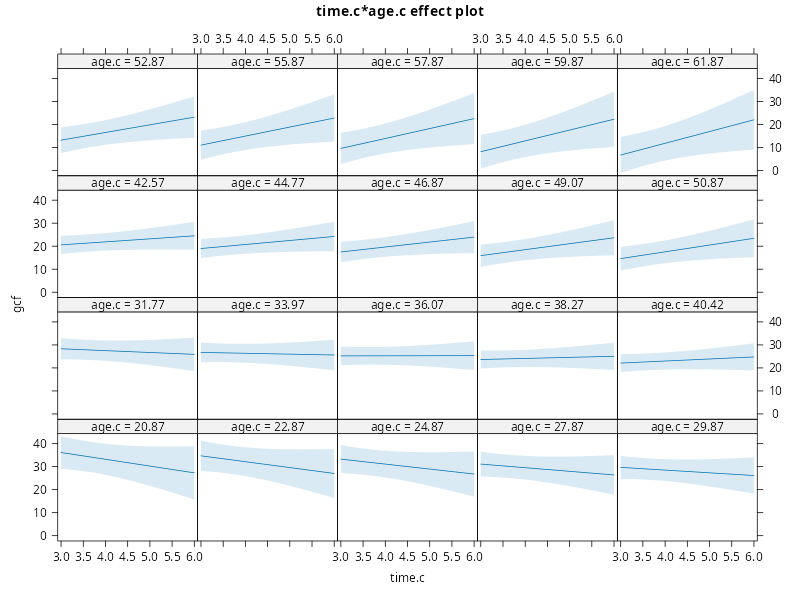

In [19]:
eff          <- effect('time.c:age.c', veneer.lme, xlevels=20)
eff$x$time.c <- round(eff$x$time.c + mean(veneer$time), 2) # add mean back in and round
eff$x$age.c  <- round(eff$x$age.c  + mean(veneer$age),  2) # add mean back in and round
plot(eff)

Now we can more easily see the effects on the original scale. The only *disadvantage* of doing this is that `effect` has chosen the 20 levels of `age` based on sensible rounded values on the *centered* scale, which does not necessarily equate to sensible rounded values on the *un-centered* scaled. So, we enm up with some weird values of `age` for each panel. We can provide `xlevels` with a list telling it which values to use for both variables, but we will leave that complexity to one side. Irrespective of the scaling, the result should be clear. As `age` increases, the slope with `time` slowly shifts from negative to positive. Patients in their 20s will show an average *decrease* in GCF over the course of 3 months. Patients in their 30s will show *no change* on average. However, patients aged 40 and above will start to show an *increase* in GCF over the course of 3 months, with this change becoming more pronounced the older they get.

The overall conclusion here is that 